# Synthetic signals

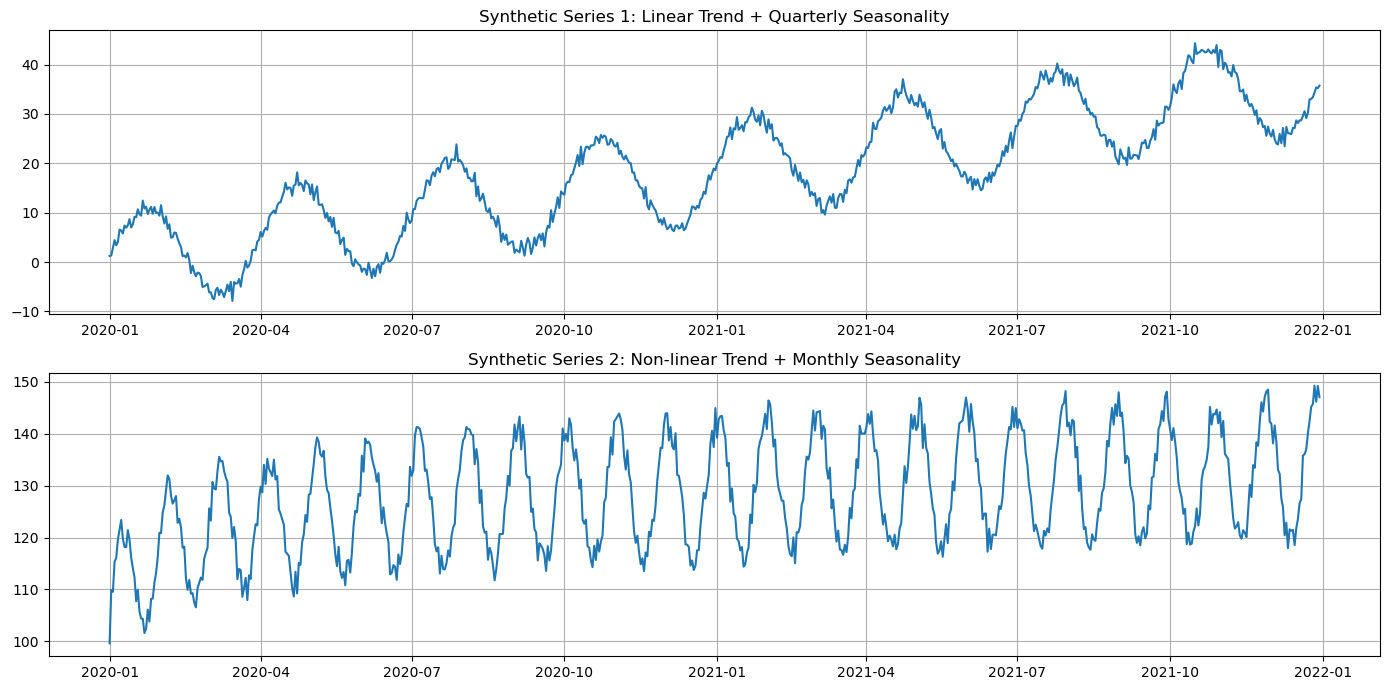

In [10]:
import numpy as np
import pandas as pd
from statsmodels.tsa.api import ExponentialSmoothing
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate synthetic time series data with known components
n = 365 * 2
t = np.arange(1,n+1)

# Series 1: Linear trend + Single seasonality + Noise
trend1 = 0.05 * t
seasonality1 = 10 * np.sin(2 * np.pi * t / (365 / 4))  # Quartertly seasonality
noise1 = np.random.normal(0, 1, n)
# Combined series
series1 = trend1 + seasonality1 + noise1
series1_components = {'trend': trend1, 'seasonal': seasonality1, 'residual': noise1}

# Series 2: Non-linear trend * seasonality * Noise

trend2 = 100 + 5 * np.log(t)
seasonality2 = 1 + 0.1 * np.sin(2 * np.pi * t / 30)
noise2 = 1 + 0.05 * (np.random.random(n) - 0.5)

series2 = trend2 * seasonality2 * noise2

# Create DataFrames for the time series
dates = pd.date_range(start='2020-01-01', periods=n, freq='D')
synthetic_df = pd.DataFrame({
    'date': dates,
    'series1': series1,
    'series2': series2,
})
synthetic_df.set_index('date', inplace=True)

# Plot the synthetic time series
plt.figure(figsize=(14, 7))

plt.subplot(2, 1, 1)
plt.plot(dates, series1)
plt.title('Synthetic Series 1: Linear Trend + Quarterly Seasonality')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(dates, series2)
plt.title('Synthetic Series 2: Non-linear Trend + Monthly Seasonality')
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# variance of time series 2

## Comparing variations of ETS error, trend, seasonality
### (1)
- for synthetic_df1: ETS(A,N,N)
- for synthetic_df2: ETS(A,N,N)

In [2]:
from utils import plot_ets

synthetic_df1 = synthetic_df['series1']
synthetic_df2 = synthetic_df['series2']

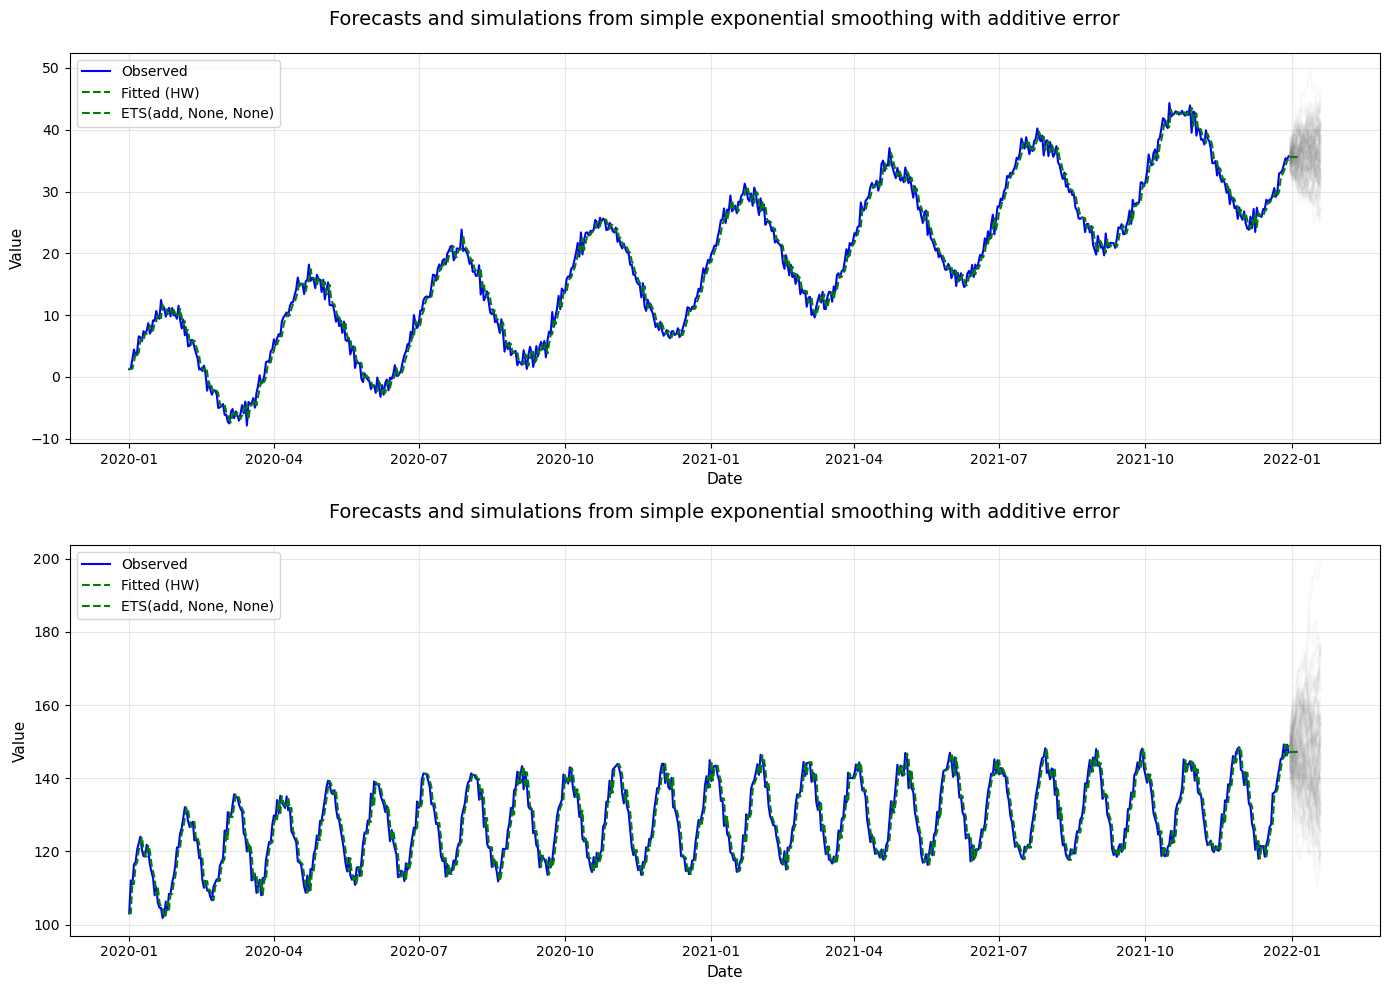

In [9]:
# simple exponential smoothing with additive error process
aic1 , aic2 = plot_ets(synthetic_df1, synthetic_df2, period=[int(365/4), int(730/30)],trend=None, seasonal= None, title='Forecasts and simulations from simple exponential smoothing with additive error', nsimulations=20, use_boxcox=(False, True))

### (2)
- for synthetic_df1: ETS(A,A,N)
- for synthetic_df2: ETS(A,A,N)

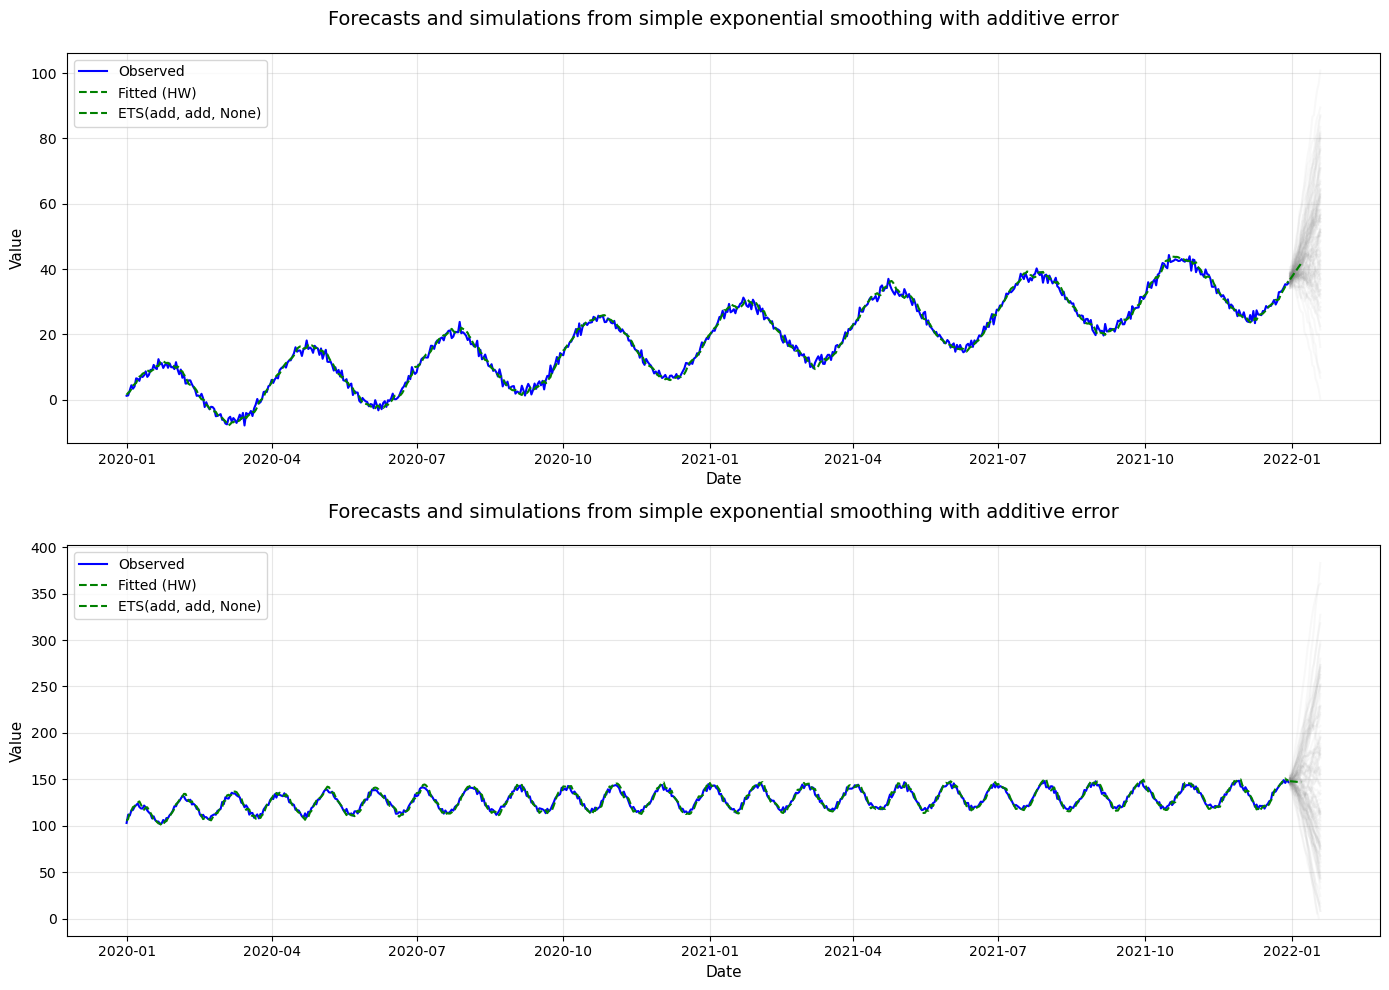

(306.0411992174055, 1593.670464541829)

In [7]:
plot_ets(synthetic_df1, synthetic_df2, period=[int(365/4), int(730/30)],trend="add", seasonal= None, title='Forecasts and simulations from simple exponential smoothing with additive error', nsimulations=20, use_boxcox=(False, True))

### (3)
- for synthetic_df1: ETS(A,A,A)
- for synthetic_df2: ETS(A,A,A)

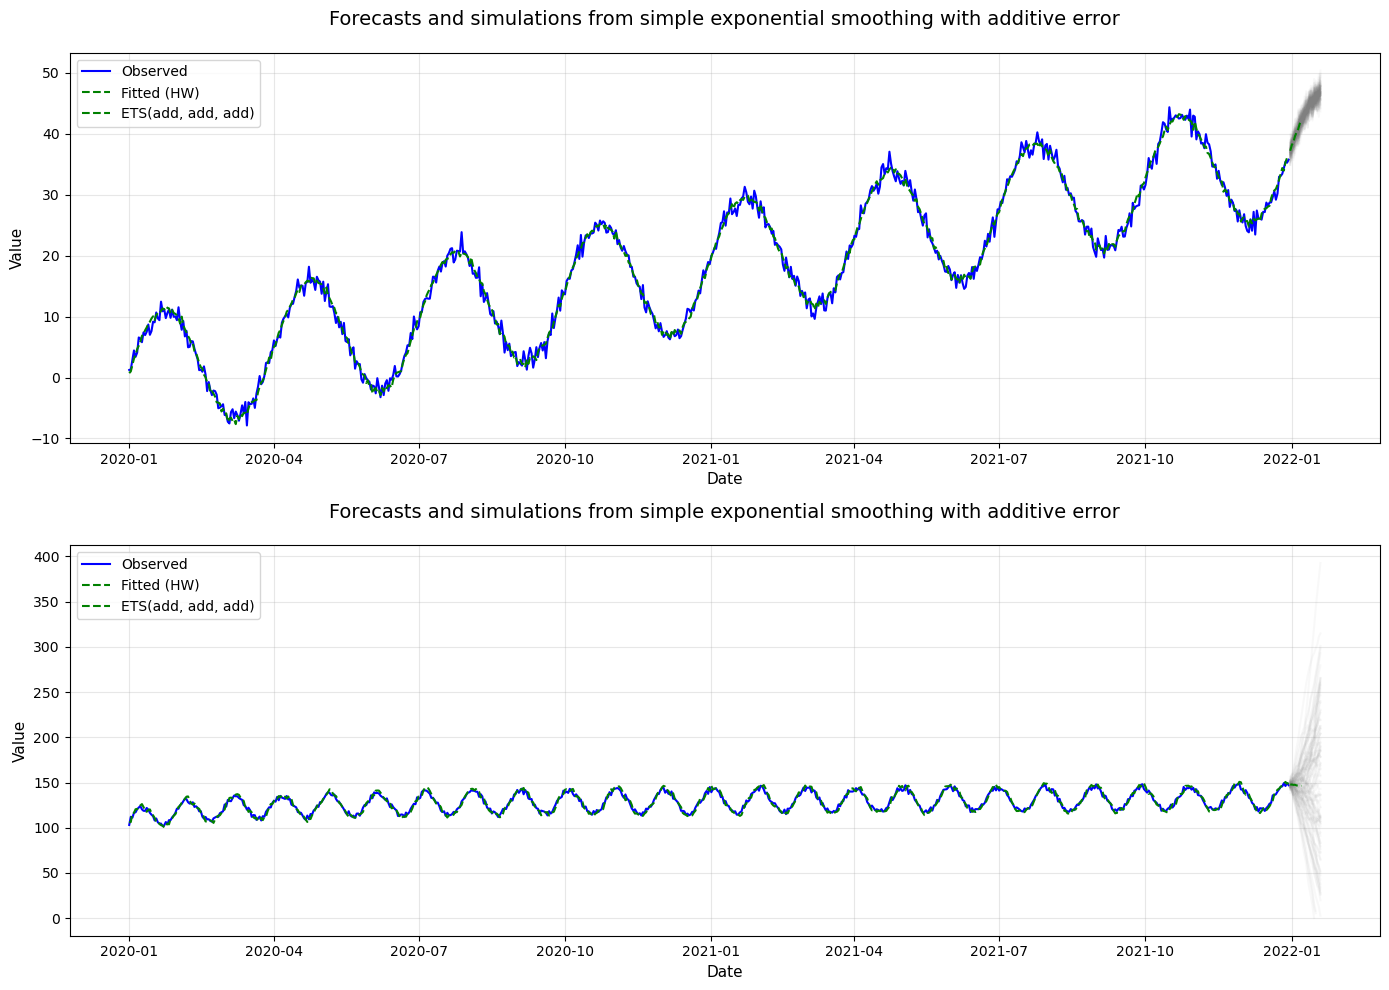

(150.25332149442346, 1623.522203380883)

In [4]:
plot_ets(synthetic_df1, synthetic_df2, period=[int(365/4), int(730/30)],trend="add", seasonal= "add", title='Forecasts and simulations from simple exponential smoothing with additive error', nsimulations=20, use_boxcox=(False, True))

### (4)
- for synthetic_df1: ETS(A,A,M)
- for synthetic_df2: ETS(A,A,M)

/home/rishabh/miniconda3/envs/ts-env/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


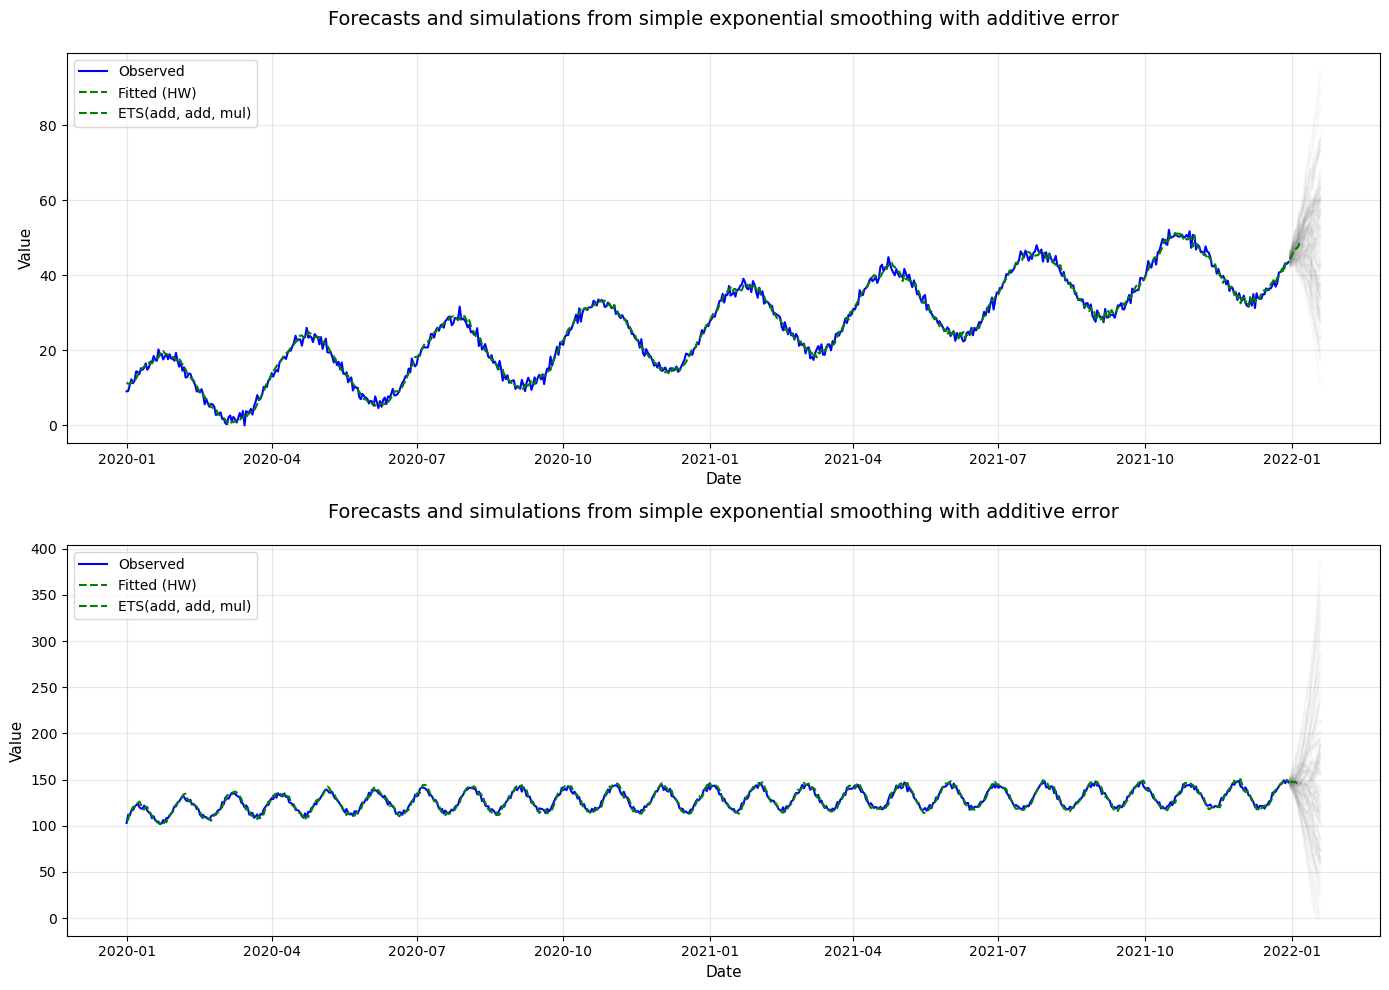

(318.01943492712235, 1623.8326383859344)

In [5]:
plot_ets(synthetic_df1, synthetic_df2, period=[int(365/4), int(730/30)],trend="add", seasonal= "mul", title='Forecasts and simulations from simple exponential smoothing with additive error', nsimulations=20, use_boxcox=(False, True))

### (5)
- for synthetic_df1: ETS(M,A,M)
- for synthetic_df2: ETS(M,A,M)

/home/rishabh/miniconda3/envs/ts-env/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


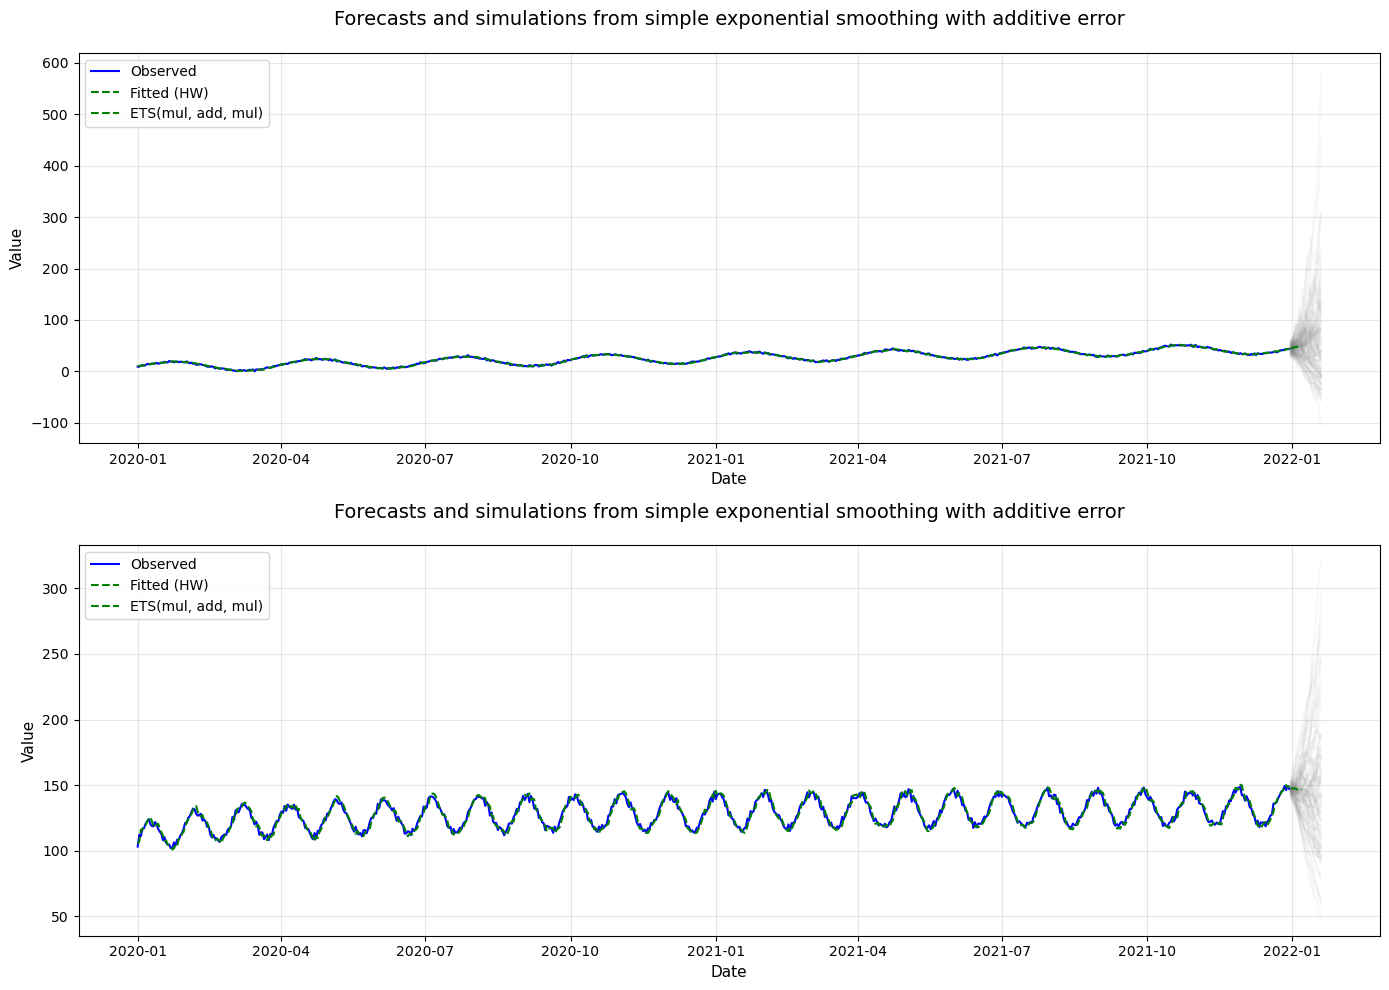

(295.66450133595856, 1586.5487555266486)

In [14]:
plot_ets(synthetic_df1, synthetic_df2, period=[int(365/4), int(730/30)],trend="add", damped_trend=True, seasonal= "mul", residual="mul", title='Forecasts and simulations from simple exponential smoothing with additive error', nsimulations=20,  use_boxcox=(False, False))

### (6)
- for synthetic_df1: ETS(A,Ad,M)
- for synthetic_df2: ETS(A,Ad,M)

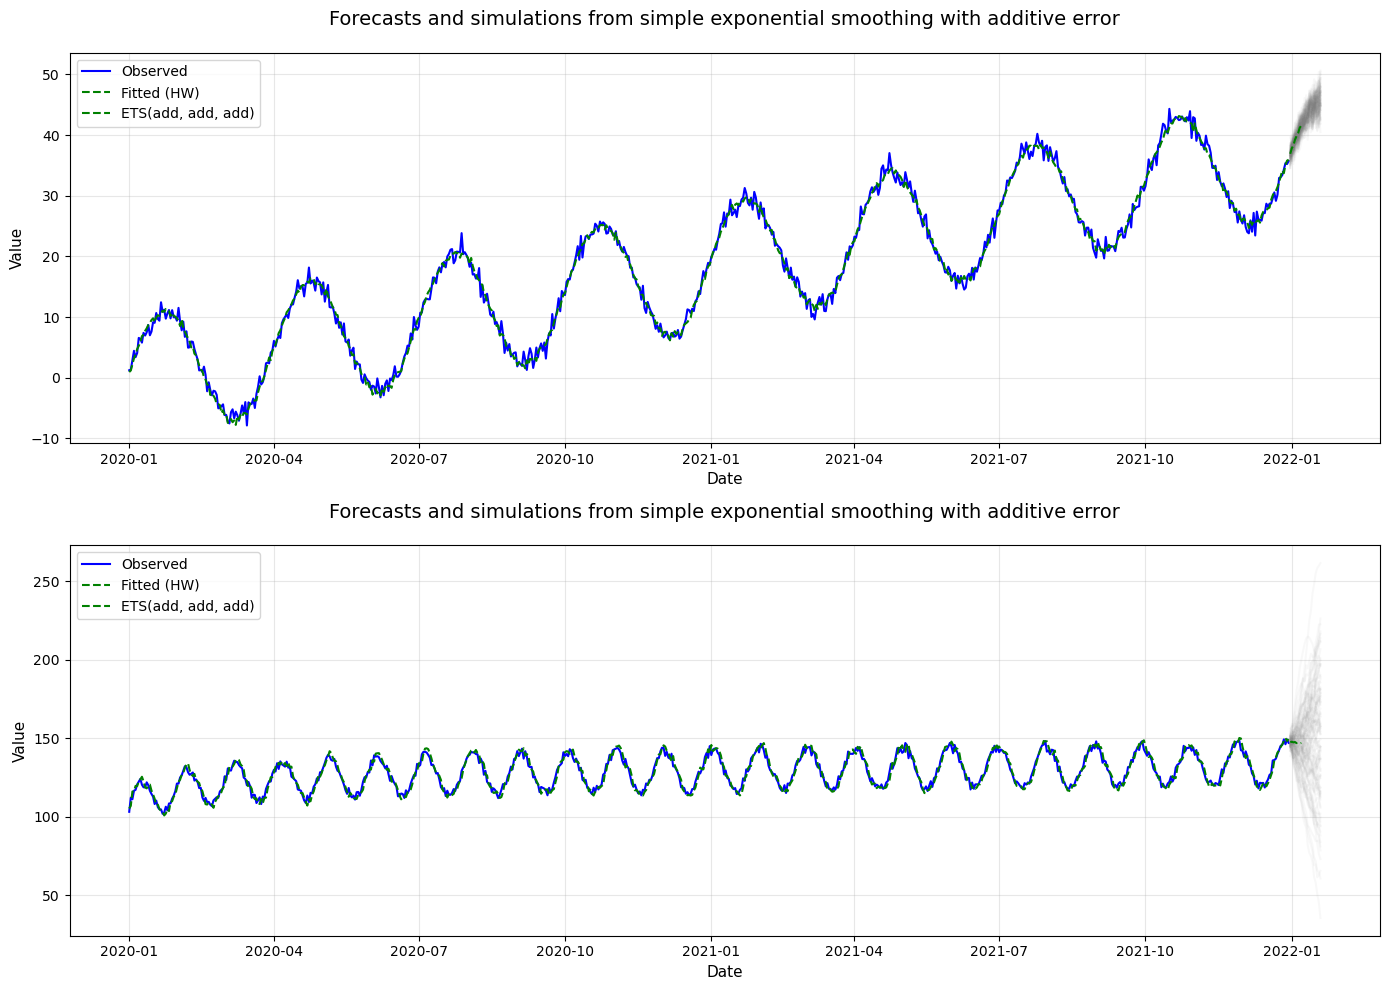

(166.88217656381093, 1586.295521920498)

In [13]:
plot_ets(synthetic_df1, synthetic_df2, period=[int(365/4), int(730/30)],trend="add", damped_trend=True, seasonal= "add", residual="add", title='Forecasts and simulations from simple exponential smoothing with additive error', nsimulations=20, use_boxcox=(False, True))

### Analysis using

# Real Data

In [1]:
from dataset import get_power_consumption, get_oil_weekly_prices
from utils import plot_ets
from statsmodels.tsa.api import ExponentialSmoothing

In [71]:
real_data1  = get_power_consumption()
real_data2 = get_oil_weekly_prices()

In [65]:
real_data1 = real_data1.iloc[0:500,:]

In [72]:
real_data1 = real_data1.resample('8h').mean()

In [66]:
import plotly.express as px
px.line(real_data1)

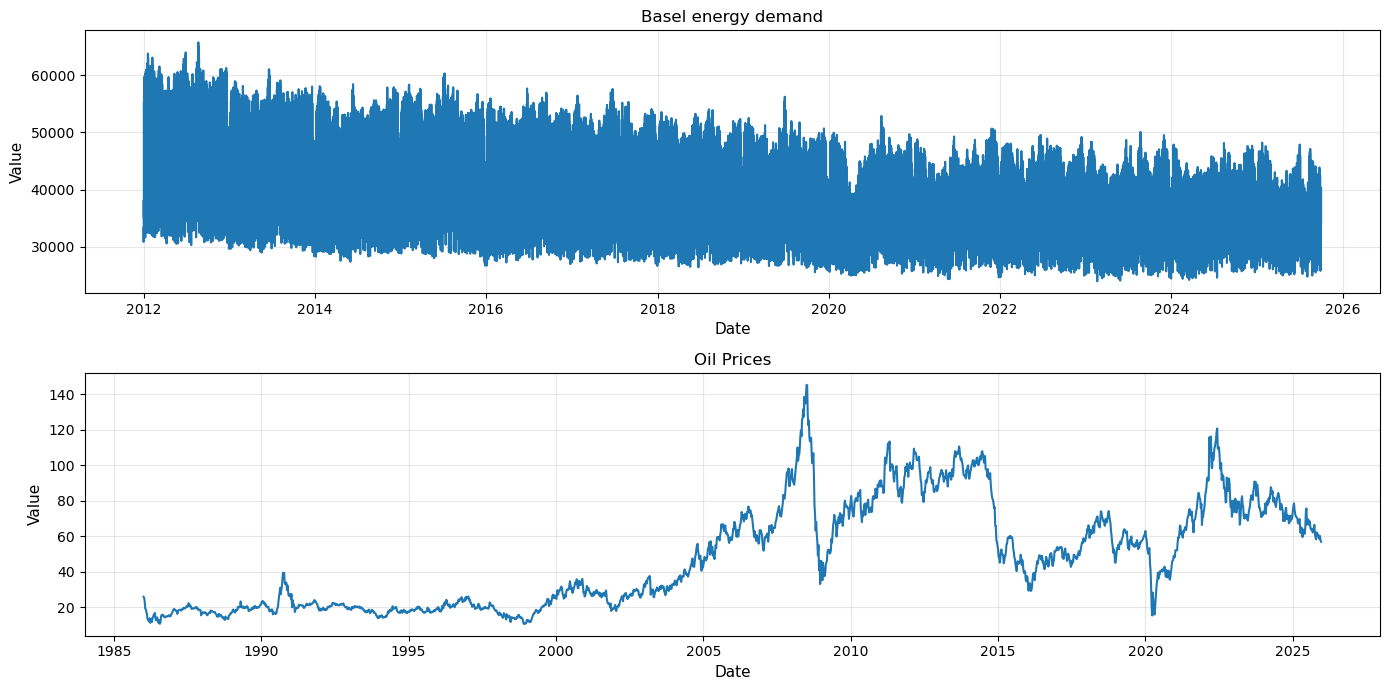

In [73]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))
ax1.plot(real_data1.index, real_data1)
ax1.set_title('Basel energy demand')
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Value', fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(real_data2.index, real_data2)

ax2.set_title('Oil Prices')
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('Value', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/home/rishabh/miniconda3/envs/ts-env/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning:

Optimization failed to converge. Check mle_retvals.



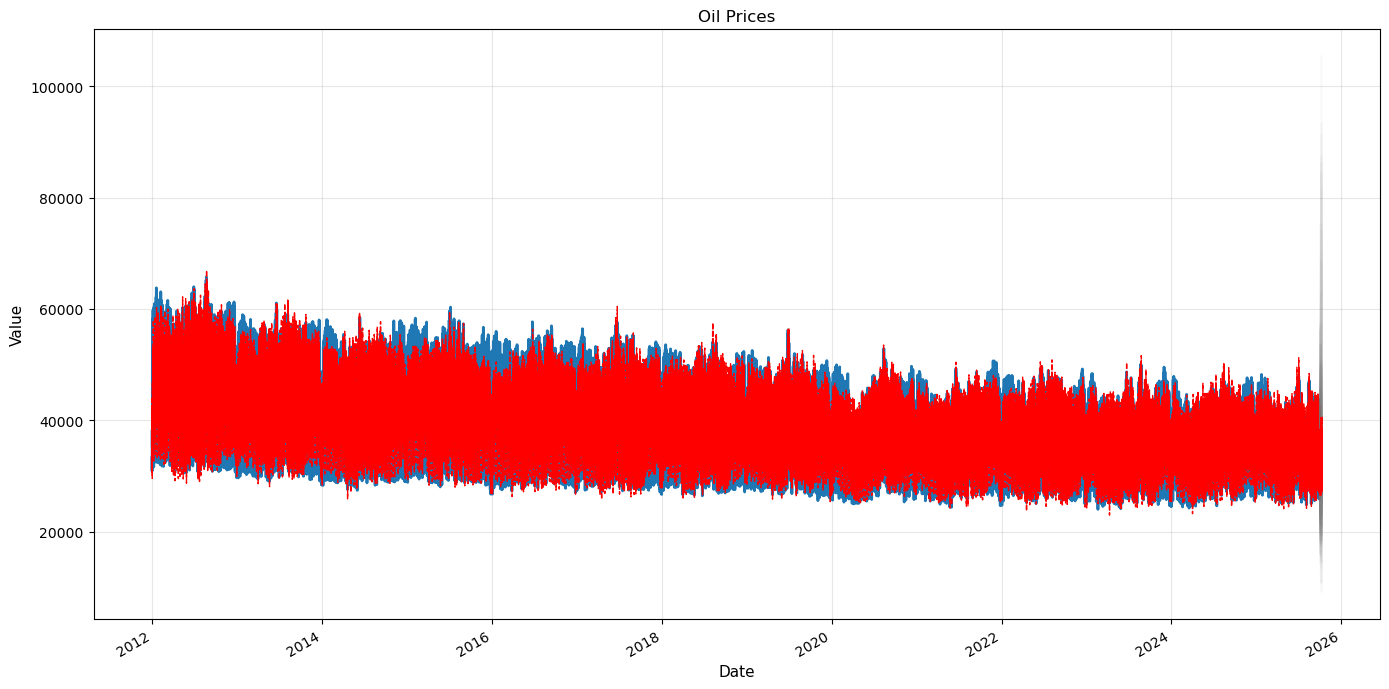

In [78]:
fit1 = ExponentialSmoothing(real_data1, trend="add",seasonal="mul", seasonal_periods=int(real_data1.size/18), initialization_method="Heuristic").fit()
simulations = fit1.simulate(20, repetitions=100, error="mul")
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(real_data1, linewidth=2)
fit1.fittedvalues.plot(ax=ax, style='--', color='red', linewidth=1)
simulations.plot(ax=ax, style='-', alpha = 0.05, color='grey', legend = False)
fit1.forecast(20).plot(ax=ax, style='--', color='red', linewidth=2)

ax.set_title('Oil Prices')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Value', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [79]:
fit1.bic

251549.12549964647